Setting directories and device

In [1]:
from google.colab import drive
import torch
import os

drive.mount('/content/drive')
notebook_path = '/content/drive/My Drive/Colab Notebooks/SC4001 AY2526 Project'
os.chdir(notebook_path)
torch.hub.set_dir(notebook_path)
print("Current working directory:", os.getcwd())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Mounted at /content/drive
Current working directory: /content/drive/My Drive/Colab Notebooks/SC4001 AY2526 Project
Using device: cpu


Importing modules and setting seeds

In [2]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, default_collate

import torchvision
from torchvision.transforms import v2
from torchvision import datasets, transforms, models

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True

Importing the oxford102 dataset

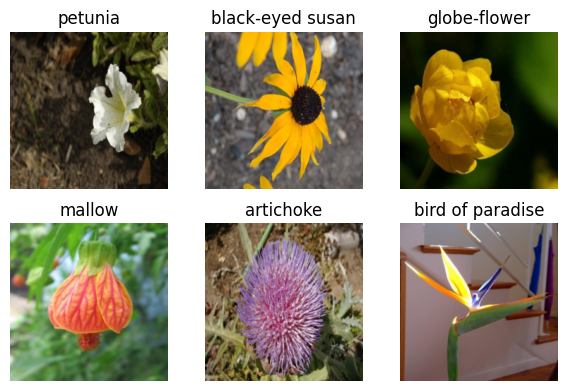


Train size:  1020
Validation size:  1020
Test size: 6149


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_data = datasets.Flowers102(
    root='./data',
    split='train',
    download=True,
    transform=transform
)
val_data = datasets.Flowers102(
    root='./data',
    split='val',
    download=True,
    transform=transform
)
test_data = datasets.Flowers102(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0)

#Visualizing a batch of images
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 3, figsize=(6, 4))
for ax, img, label in zip(axes.flat, images[:6], labels[:6]):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(train_data.classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

#Size of each dataset
print("\nTrain size: ", len(train_data))
print("Validation size: ", len(val_data))
print("Test size:", len(test_data))

Check the class distributions of the datasets

In [4]:
sets = [train_data, val_data, test_data]
names = ['Train', 'Val', 'Test']
df = pd.DataFrame({
    'Class': train_data.classes
})

for dataset, name in (zip(sets, names)):
    # Access labels directly without loading images
    labels = dataset._labels
    df[name + ' Count'] = pd.Series(labels).value_counts()

# Get TRAIN_INDICES for later use. Contains the index positions of each class
train_labels_np = np.array(train_data._labels)
TRAIN_INDICES = {i: np.where(train_labels_np == i)[0].tolist() for i in range(len(train_data.classes))}

df['Total Count'] = df[['Train Count', 'Val Count', 'Test Count']].sum(axis=1)
display(df.head())
display(df.describe())

,Class,Train Count,Val Count,Test Count,Total Count
0,pink primrose,10,10,20,40
1,hard-leaved pocket orchid,10,10,40,60
2,canterbury bells,10,10,20,40
3,sweet pea,10,10,36,56
4,english marigold,10,10,45,65


,Train Count,Val Count,Test Count,Total Count
count,102.0,102.0,102.000000,102.000000
mean,10.0,10.0,60.284314,80.284314
std,0.0,0.0,44.276891,44.276891
min,10.0,10.0,20.000000,40.000000
25%,10.0,10.0,29.000000,49.000000
50%,10.0,10.0,46.000000,66.000000
75%,10.0,10.0,72.750000,92.750000
max,10.0,10.0,238.000000,258.000000


DATASET SUMMARY (Flowers102)
Number of classes: 102
Train set  : 1020 images (10 per class, balanced)
Validation set: 1020 images (10 per class, balanced)
Test set   : 6149 images (variable per class)

Test set per-class distribution:
  Min images/class  : 20
  Max images/class  : 238
  Mean images/class : 60.28
  Std dev           : 44.06


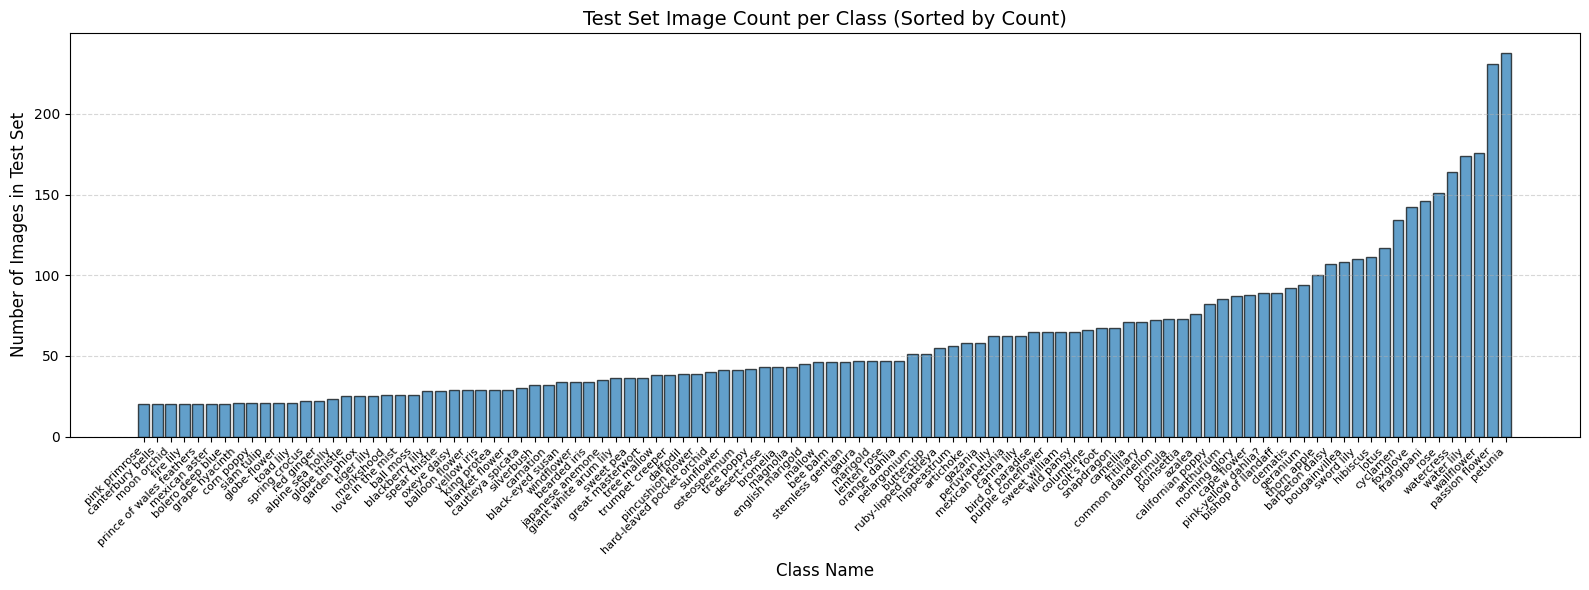

In [5]:
# --- Overall summary ---
print("="*50)
print("DATASET SUMMARY (Flowers102)")
print("="*50)
print(f"Number of classes: {len(train_data.classes)}")
print(f"Train set  : {len(train_data)} images (10 per class, balanced)")
print(f"Validation set: {len(val_data)} images (10 per class, balanced)")
print(f"Test set   : {len(test_data)} images (variable per class)")

# --- Test set distribution statistics ---
test_counts = df['Test Count'].values
print("\nTest set per-class distribution:")
print(f"  Min images/class  : {test_counts.min()}")
print(f"  Max images/class  : {test_counts.max()}")
print(f"  Mean images/class : {test_counts.mean():.2f}")
print(f"  Std dev           : {test_counts.std():.2f}")

# Sort classes by Test Count (ascending order)
sorted_df = df.sort_values('Test Count')

plt.figure(figsize=(16, 6))
plt.bar(sorted_df['Class'], sorted_df['Test Count'], edgecolor='black', alpha=0.7)
plt.xlabel('Class Name', fontsize=12)
plt.ylabel('Number of Images in Test Set', fontsize=12)
plt.title('Test Set Image Count per Class (Sorted by Count)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Choose the pretrained torchvision models that will be used on the dataset and create a function to appropriately configure them for the dataset

In [6]:
# Define model configurations as a list of dicts
model_configs = [
    {
        "name": "VGG-11_BN",
        "model_fn": models.vgg11_bn,
        "weights": models.VGG11_BN_Weights.IMAGENET1K_V1,
        "classifier_attr": "classifier",
        "classifier_layer_index": -1   # VGG: last layer of classifier
    },
    {
        "name": "ResNet18",
        "model_fn": models.resnet18,
        "weights": models.ResNet18_Weights.IMAGENET1K_V1,
        "classifier_attr": "fc",
        "classifier_layer_index": None  # ResNet: just replace model.fc
    },
    {
        "name": "Swin_T",
        "model_fn": models.swin_t,
        "weights": models.Swin_T_Weights.IMAGENET1K_V1,
        "classifier_attr": "head",
        "classifier_layer_index": None # Swin_T: just replace model.head
    }
]

BATCH_SIZE = 128
NUM_FLOWER_CLASSES = 102

def process_cfg(cfg):
    """Processes a model config to return the model with corrected output shape"""
    # Load pre-trained model
    model = cfg["model_fn"](weights=cfg["weights"])

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace the classifier head
    if cfg["classifier_layer_index"] is not None:
        # For VGG: classifier is a Sequential, replace the last layer
        classifier = getattr(model, cfg["classifier_attr"])
        in_features = classifier[cfg["classifier_layer_index"]].in_features
        classifier[cfg["classifier_layer_index"]] = nn.Linear(in_features, NUM_FLOWER_CLASSES)
    else:
        # For ResNet and Swin: directly replace fc or head
        classifier = getattr(model, cfg["classifier_attr"])
        in_features = classifier.in_features
        setattr(model, cfg["classifier_attr"], nn.Linear(in_features, NUM_FLOWER_CLASSES))

    return model

Create helper functions/classes for a model's training, validation and testing phases and a function `reduce` to resize the training set for the k-shot learning experiments


In [7]:
class EarlyStopper:
    def __init__(self, patience=5, min_delta=0.1):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf

    #Stops training if validation loss fails to improve by at least {min_delta} for {patience} consecutive epochs.
    def early_stop(self, validation_loss):
        if validation_loss < (self.min_validation_loss - self.min_delta):
            self.min_validation_loss = validation_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

def compute_correct(outputs, labels):
    """Compute number of correct predictions."""
    _, predictions = torch.max(outputs, dim=1)
    return (predictions == labels).sum().item()

def train(model, tl, vl, epochs=100):
    """Trains model on train set and evaluates on validation set for early stopping"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.cuda.empty_cache()
    model = model.to(device)

    print(f"Training {model.name} on device: {device}")

    early_stopper = EarlyStopper()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=0.0005)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    train_accuracies, train_losses, val_accuracies, val_losses, times = [], [], [], [], epochs

    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        epoch_train_correct = 0
        for X_batch, y_batch in tl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
            epoch_train_correct += compute_correct(outputs, y_batch)
        avg_train_loss = epoch_train_loss / len(tl)
        avg_train_acc = epoch_train_correct / len(tl.dataset)

        # Validation phase
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in vl:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                epoch_val_loss += loss.item()
                epoch_val_correct += compute_correct(outputs, y_batch)
        avg_val_loss = epoch_val_loss / len(vl)
        avg_val_acc = epoch_val_correct / len(vl.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(avg_train_acc)
        val_accuracies.append(avg_val_acc)
        scheduler.step()

        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] "
                f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}, "
                f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")

        # Early stopping check (using val loss)
        if early_stopper.early_stop(avg_val_loss):
            times = epoch + 1
            print(f"Early stopping triggered at epoch {times}")
            break

    print(f"\nFinal Train Accuracy: {train_accuracies[-1]:.4f}")
    print(f"Final Val Accuracy: {val_accuracies[-1]:.4f}")

    return train_accuracies, train_losses, val_accuracies, val_losses, times

def test(model, ttl):
    """Evaluates model on test set"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.cuda.empty_cache()
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()

    print(f"Testing {model.name} on device: {device}")

    # Testing phase
    model.eval()
    test_loss = 0.0
    test_correct = 0
    with torch.no_grad():
        for X_batch, y_batch in ttl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            test_loss += loss.item()
            test_correct += compute_correct(outputs, y_batch)
    avg_test_loss = test_loss / len(ttl)
    avg_test_acc = test_correct / len(ttl.dataset)

    print(f"Test Loss: {avg_test_loss:.4f}, Test Acc: {avg_test_acc:.4f}")

    return avg_test_acc, avg_test_loss

def reduce(dataset, k, class_indices):
    """Returns a subset of the dataset with the first k images encountered for each class."""
    subset_indices = []
    for indices in class_indices.values():
        subset_indices.extend(indices[:k])
    return Subset(dataset, subset_indices)

Conduct the k shot learning experiments for each model architecture for each k value

In [8]:
few_shot_results = []
for cfg in model_configs:
    print(f"\n--- Processing {cfg['name']} ---")

    # Get the official transform
    transform = cfg["weights"].transforms()

    # Create datasets (each model architecture gets its own, but they share the same downloaded images)
    train_dataset = datasets.Flowers102(root='./data', split='train', download=True, transform=transform)
    val_dataset   = datasets.Flowers102(root='./data', split='val',   download=True, transform=transform)
    test_dataset  = datasets.Flowers102(root='./data', split='test',  download=True, transform=transform)

    # Create the val and test dataloaders (fixed for each k shot learning)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    for k in [1,2,5,10]:
        # Get the reduced dataset and dataloader for k shot learning
        reduced_dataset = reduce(train_dataset, k, TRAIN_INDICES) # TRAIN_INDICES: Contains the index positions of each class
        train_loader = DataLoader(reduced_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)

        # Load processed model
        model = process_cfg(cfg)
        model.name = cfg["name"] + f"_{k}shot"
        save_path = './checkpoints/' + model.name + '.pth'

        if os.path.exists(save_path):
            print(f"\nLoading results from {save_path}")
            ckpt = torch.load(save_path, map_location=device)
            trv_results = ckpt["trv_results"]
            t_results =  ckpt["t_results"]
        else:
            print(f"\n{save_path} does not exist, training from scratch...")
            trv_results = train(model, train_loader, val_loader)
            t_results = test(model, test_loader)

            # Save model state dict
            torch.save({
                'model_state_dict': model.state_dict(),
                'trv_results': trv_results,
                't_results': t_results
            }, save_path)
            print(f"Model saved successfully to {save_path}")

        few_shot_results.append({
            "name": model.name,
            "trv_results": trv_results,
            "t_results": t_results
        })

        # After training, delete to free memory
        del model, train_loader, reduced_dataset


--- Processing VGG-11_BN ---

Loading results from ./checkpoints/VGG-11_BN_1shot.pth

Loading results from ./checkpoints/VGG-11_BN_2shot.pth

Loading results from ./checkpoints/VGG-11_BN_5shot.pth

Loading results from ./checkpoints/VGG-11_BN_10shot.pth

--- Processing ResNet18 ---

Loading results from ./checkpoints/ResNet18_1shot.pth

Loading results from ./checkpoints/ResNet18_2shot.pth

Loading results from ./checkpoints/ResNet18_5shot.pth

Loading results from ./checkpoints/ResNet18_10shot.pth

--- Processing Swin_T ---

Loading results from ./checkpoints/Swin_T_1shot.pth

Loading results from ./checkpoints/Swin_T_2shot.pth

Loading results from ./checkpoints/Swin_T_5shot.pth

Loading results from ./checkpoints/Swin_T_10shot.pth


Parse the results from the k shot learning experiments and show some of the results as tables and plots

FEW-SHOT LEARNING RESULTS SUMMARY
    Model  k  Epochs Ran  Final Train Acc (%)  Final Val Acc (%)  Final Train Loss  Final Val Loss  Test Acc (%)  Test Loss
VGG-11_BN  1          16               100.00              42.94            0.0009          2.4165         38.72     2.5843
VGG-11_BN  2          13               100.00              53.43            0.0034          2.0010         50.72     2.1773
VGG-11_BN  5           9               100.00              75.29            0.0106          1.0215         71.10     1.1580
VGG-11_BN 10           9                99.90              83.63            0.0162          0.6372         80.99     0.7253
 ResNet18  1          19               100.00              30.29            0.0353          3.0746         26.39     3.2256
 ResNet18  2          18               100.00              55.39            0.1412          2.2867         50.71     2.3754
 ResNet18  5          17               100.00              75.69            0.1083          1.2803

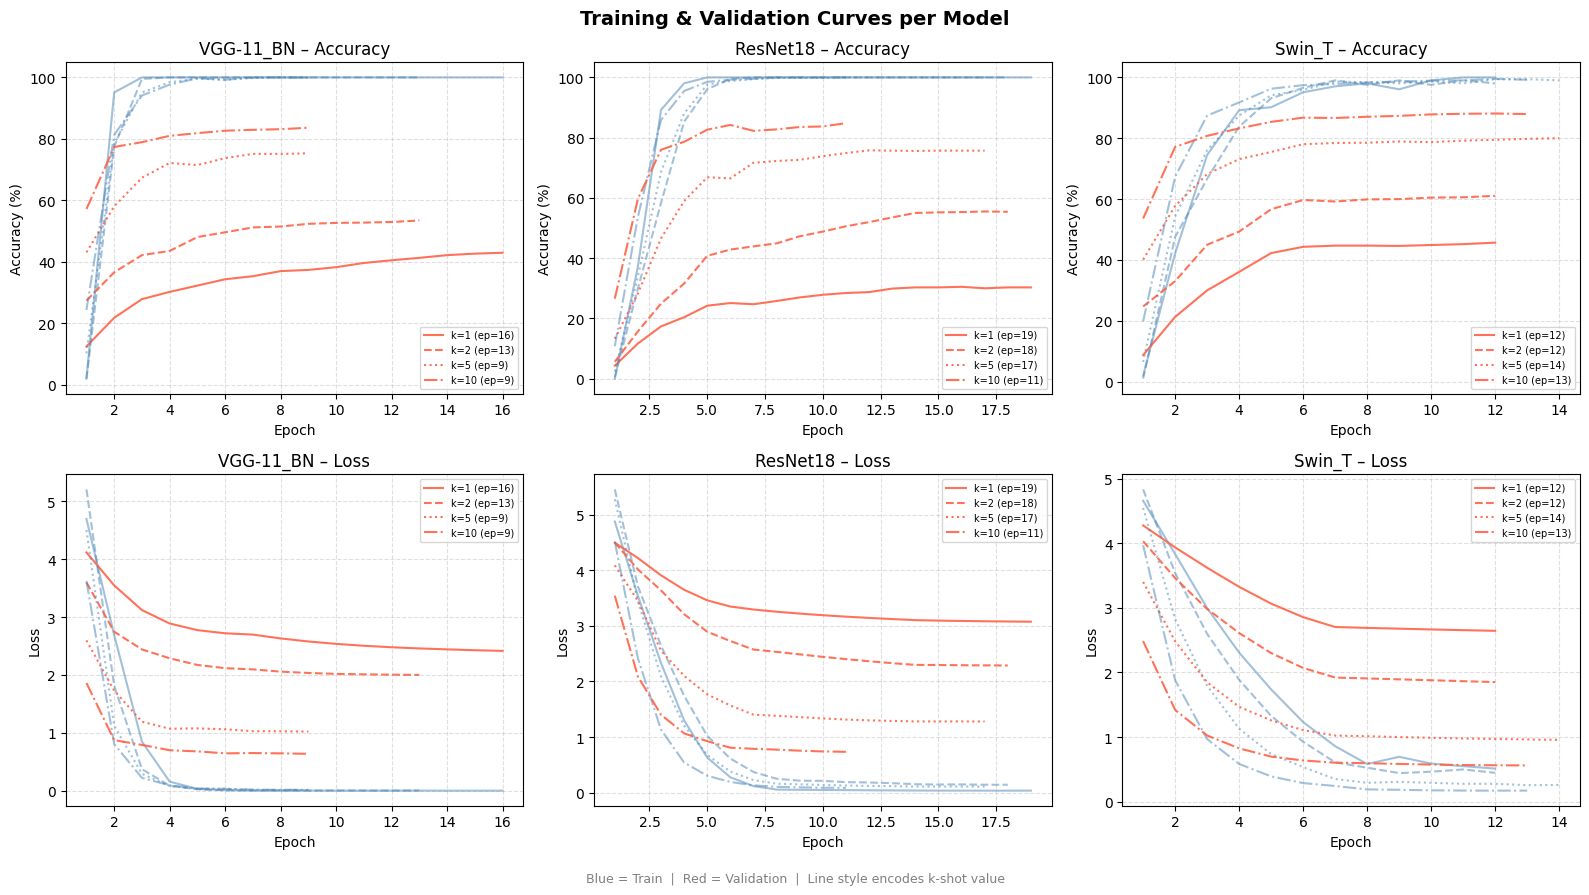

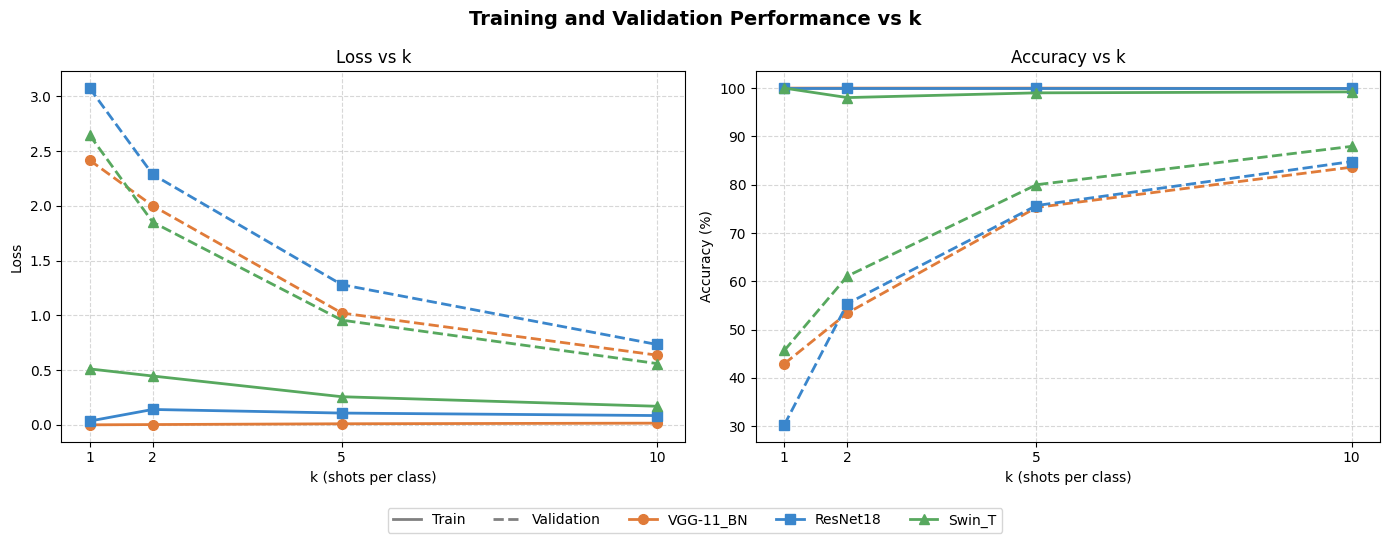

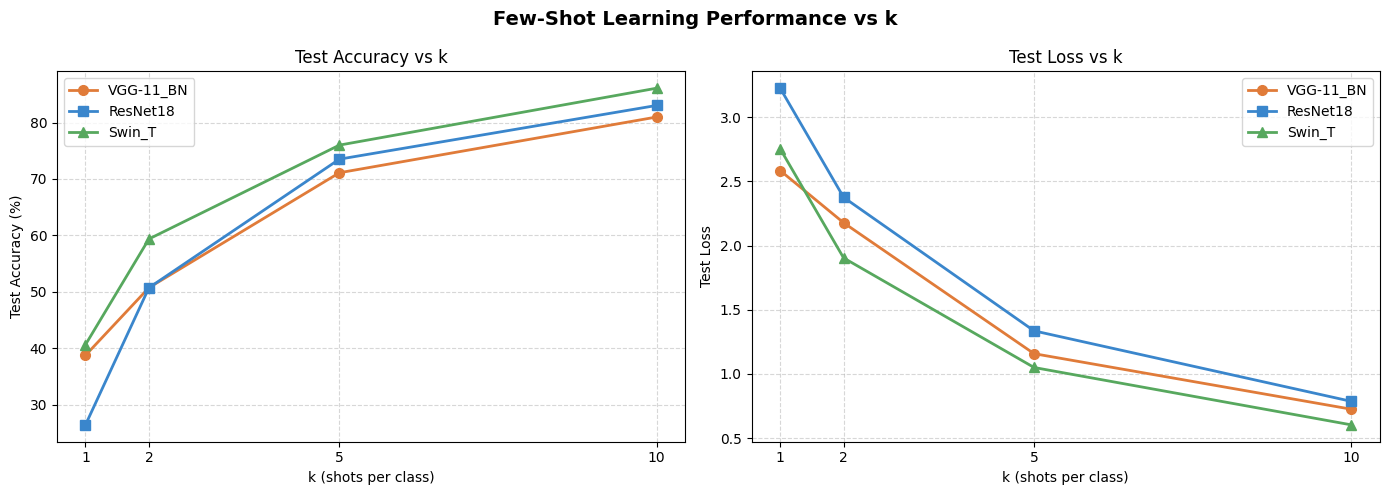

In [9]:
# Parse few_shot_results
models_list  = ['VGG-11_BN', 'ResNet18', 'Swin_T']
k_values     = [1, 2, 5, 10]

rows = []
for entry in few_shot_results:
    name = entry['name']                       # e.g. 'ResNet18_2shot'
    train_accs, train_losses, val_accs, val_losses, epochs_ran = entry['trv_results']
    test_acc, test_loss = entry['t_results']

    # Parse model name and k from the stored name string
    parts  = name.rsplit('_', 1)               # ['ResNet18', '2shot']
    model  = parts[0]
    k      = int(parts[1].replace('shot', ''))

    rows.append({
        'Model':               model,
        'k':                   k,
        'Epochs Ran':          epochs_ran,
        'Final Train Acc (%)': round(train_accs[-1]  * 100, 2),
        'Final Train Loss':    round(train_losses[-1],      4),
        'Final Val Acc (%)':   round(val_accs[-1]    * 100, 2),
        'Final Val Loss':      round(val_losses[-1],        4),
        'Test Acc (%)':        round(test_acc        * 100, 2),
        'Test Loss':           round(test_loss,             4),
        # keep raw lists for plotting
        '_train_accs':         train_accs,
        '_val_accs':           val_accs,
        '_train_losses':       train_losses,
        '_val_losses':         val_losses
    })

df_full = pd.DataFrame(rows)

# Summary tables
display_cols = ['Model', 'k', 'Epochs Ran',
                'Final Train Acc (%)', 'Final Val Acc (%)', 'Final Train Loss','Final Val Loss',
                'Test Acc (%)', 'Test Loss']

print("="*105)
print("FEW-SHOT LEARNING RESULTS SUMMARY")
print("="*105)
print(df_full[display_cols].to_string(index=False))

# Best val accuracy per model
print("\n" + "─"*105)
print("BEST VAL ACCURACY PER MODEL ARCHITECTURE")
print("─"*105)
best = df_full.loc[df_full.groupby('Model')['Final Val Acc (%)'].idxmax(),
                   ['Model', 'k', 'Final Val Acc (%)', 'Final Val Loss']]
print(best.to_string(justify="center", index=False), "\n")

# Color palette
COLORS  = {'VGG-11_BN': '#e07b39', 'ResNet18': '#3a86cc', 'Swin_T': '#57a85e'}
MARKERS = {'VGG-11_BN': 'o',       'ResNet18': 's',        'Swin_T': '^'}
STYLES  = ['-', '--', ':', '-.']

# Plots: Training curves – accuracy and loss per model architecture (2×3 grid)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Training & Validation Curves per Model', fontsize=14, fontweight='bold')

for col, model in enumerate(models_list):
    sub = df_full[df_full['Model'] == model].sort_values('k')
    ax_acc  = axes[0][col]
    ax_loss = axes[1][col]

    for idx, (_, row) in enumerate(sub.iterrows()):
        k       = row['k']
        ep      = row['Epochs Ran']
        epochs  = range(1, len(row['_train_accs']) + 1)
        style   = STYLES[idx]
        label   = f'k={k} (ep={ep})'

        ax_acc.plot(epochs, [a * 100 for a in row['_train_accs']],
                    linestyle=style, color='steelblue', alpha=0.5)
        ax_acc.plot(epochs, [a * 100 for a in row['_val_accs']],
                    linestyle=style, color='tomato',    alpha=0.9,
                    label=label)

        ax_loss.plot(epochs, row['_train_losses'],
                     linestyle=style, color='steelblue', alpha=0.5)
        ax_loss.plot(epochs, row['_val_losses'],
                     linestyle=style, color='tomato',    alpha=0.9,
                     label=label)

    ax_acc.set(title=f'{model} – Accuracy',
               xlabel='Epoch', ylabel='Accuracy (%)')
    ax_acc.legend(fontsize=7); ax_acc.grid(True, linestyle='--', alpha=0.4)

    ax_loss.set(title=f'{model} – Loss',
                xlabel='Epoch', ylabel='Loss')
    ax_loss.legend(fontsize=7); ax_loss.grid(True, linestyle='--', alpha=0.4)

# Shared legend hint
fig.text(0.5, 0.01,
         'Blue = Train  |  Red = Validation  |  Line style encodes k-shot value',
         ha='center', fontsize=9, color='gray')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

# Plots: Final Train & Val Loss and Accuracy vs k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training and Validation Performance vs k', fontsize=14, fontweight='bold')

for model in models_list:
    sub = df_full[df_full['Model'] == model].sort_values('k')
    axes[0].plot(sub['k'], sub['Final Train Loss'],
                 marker=MARKERS[model], color=COLORS[model],
                 linewidth=2, markersize=7, linestyle='-')
    axes[0].plot(sub['k'], sub['Final Val Loss'],
                 marker=MARKERS[model], color=COLORS[model],
                 linewidth=2, markersize=7, linestyle='--')
    axes[1].plot(sub['k'], sub['Final Train Acc (%)'],
                 marker=MARKERS[model], color=COLORS[model],
                 linewidth=2, markersize=7, linestyle='-')
    axes[1].plot(sub['k'], sub['Final Val Acc (%)'],
                 marker=MARKERS[model], color=COLORS[model],
                 linewidth=2, markersize=7, linestyle='--')

for ax, title, ylabel in zip(axes,
                              ['Loss vs k', 'Accuracy vs k'],
                              ['Loss', 'Accuracy (%)']):
    ax.set(title=title, xlabel='k (shots per class)', ylabel=ylabel, xticks=k_values)
    ax.grid(True, linestyle='--', alpha=0.5)

# Shared legend: line style entries + color/model entries
style_handles = [
    plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='-',  label='Train'),
    plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='--', label='Validation'),
]
color_handles = [
    plt.Line2D([0], [0], color=COLORS[m], linewidth=2, marker=MARKERS[m], markersize=7, label=m)
    for m in models_list
]
fig.legend(handles=style_handles + color_handles,
           loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08), frameon=True)

plt.tight_layout()
plt.show()

# Plots: Test Accuracy and Loss vs k (line plot per model architecture)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Few-Shot Learning Performance vs k', fontsize=14, fontweight='bold')

for model in models_list:
    sub = df_full[df_full['Model'] == model].sort_values('k')
    axes[0].plot(sub['k'], sub['Test Acc (%)'],
                 marker=MARKERS[model], color=COLORS[model],
                 linewidth=2, markersize=7, label=model)
    axes[1].plot(sub['k'], sub['Test Loss'],
                 marker=MARKERS[model], color=COLORS[model],
                 linewidth=2, markersize=7, label=model)

axes[0].set(title='Test Accuracy vs k', xlabel='k (shots per class)',
            ylabel='Test Accuracy (%)', xticks=k_values)
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set(title='Test Loss vs k', xlabel='k (shots per class)',
            ylabel='Test Loss', xticks=k_values)
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()